In [ ]:
# Thư viện để phân tích dữ liệu, thao tác với dữ liệu dạng bảng, chuỗi thời gian.
import pandas as pd
# Thư viện để tính toán khoa học, xử lý mảng và ma trận.
import numpy as np
# Thư viện để tạo đồ thị và hình ảnh hóa dữ liệu.
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import plotly.express as px
#thiết lập kiểu đồ thị mặc định
matplotlib.style.use('ggplot')
#chuẩn hóa và tiền xử lý dữ liệu
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
# Bỏ qua các cảnh báo không cần thiết
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/heart_failure_clinical_records.csv')

In [ ]:
df.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,748,0,45,0,263358.03,1.3,137,1,1,88,0
1,65.0,0,56,0,25,0,305000.00,5.0,130,1,0,207,0
2,45.0,0,582,1,38,0,319000.00,0.9,140,0,0,244,0
3,60.0,1,754,1,40,1,328000.00,1.2,126,1,0,90,0
4,95.0,1,582,0,30,0,461000.00,2.0,132,1,0,50,1
5,70.0,0,232,1,30,0,302000.00,1.2,132,1,0,210,0
6,63.0,1,122,1,60,0,172000.00,1.2,145,0,0,147,0
7,70.0,1,171,0,50,1,358000.00,0.9,141,0,0,196,0
8,50.0,0,482,1,30,0,300000.00,0.9,132,1,0,109,0
9,53.0,1,446,0,45,1,274000.00,1.0,133,1,0,215,0


In [ ]:
#Kiểm tra kiểu dữ liệu các cột
df.dtypes

,0
age,float64
anaemia,int64
creatinine_phosphokinase,int64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64


In [ ]:
#Mô tả dữ liệu
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,60.288736,11.697243,40.0,50.0,60.00,68.0,95.0
anaemia,5000.0,0.474400,0.499394,0.0,0.0,0.00,1.0,1.0
creatinine_phosphokinase,5000.0,586.760600,976.733979,23.0,121.0,248.00,582.0,7861.0
diabetes,5000.0,0.439400,0.496364,0.0,0.0,0.00,1.0,1.0
ejection_fraction,5000.0,37.734600,11.514855,14.0,30.0,38.00,45.0,80.0
high_blood_pressure,5000.0,0.364800,0.481422,0.0,0.0,0.00,1.0,1.0
platelets,5000.0,265075.404370,97999.758622,25100.0,215000.0,263358.03,310000.0,850000.0
serum_creatinine,5000.0,1.369106,1.009750,0.5,0.9,1.10,1.4,9.4
serum_sodium,5000.0,136.808200,4.464236,113.0,134.0,137.00,140.0,148.0
sex,5000.0,0.645600,0.478379,0.0,0.0,1.00,1.0,1.0


In [ ]:
#Thông tin các cột
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   float64
 1   anaemia                   5000 non-null   int64  
 2   creatinine_phosphokinase  5000 non-null   int64  
 3   diabetes                  5000 non-null   int64  
 4   ejection_fraction         5000 non-null   int64  
 5   high_blood_pressure       5000 non-null   int64  
 6   platelets                 5000 non-null   float64
 7   serum_creatinine          5000 non-null   float64
 8   serum_sodium              5000 non-null   int64  
 9   sex                       5000 non-null   int64  
 10  smoking                   5000 non-null   int64  
 11  time                      5000 non-null   int64  
 12  DEATH_EVENT               5000 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 507.9 KB


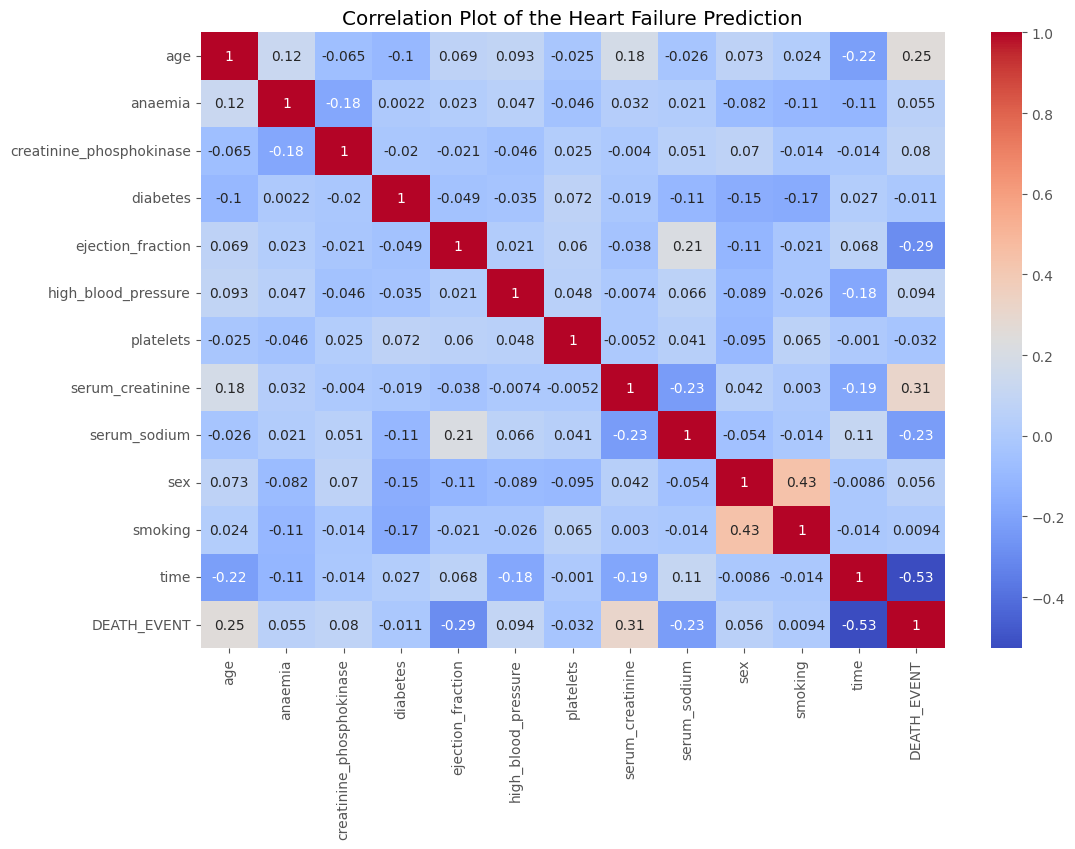

In [ ]:
#tính toán ma trận tương quan
corr_matrix = df.corr()
#trực quan hoá ma trận bằng heatmap
plt.figure(figsize=(12, 8))
ax  = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
ax.set_title('Correlation Plot of the Heart Failure Prediction')
plt.show()

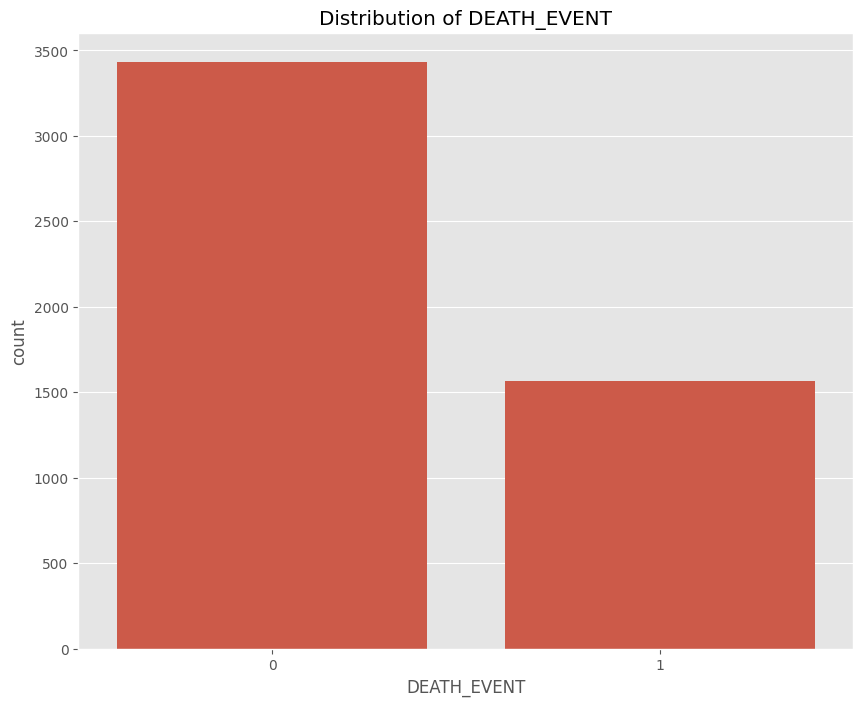

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.countplot(x='DEATH_EVENT', data=df)
ax.set_title('Distribution of DEATH_EVENT')
plt.show()

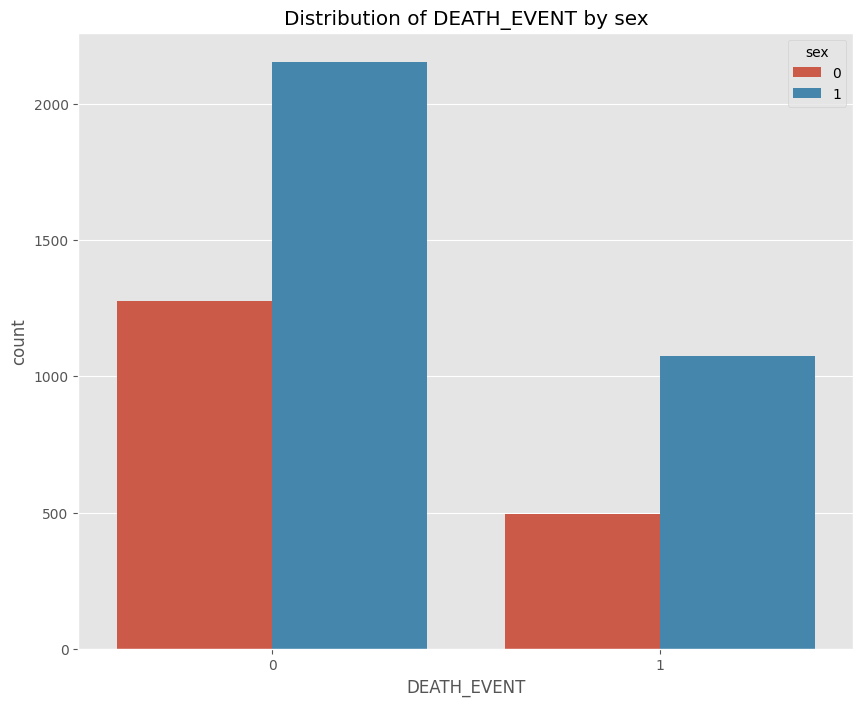

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.countplot(x='DEATH_EVENT', hue = 'sex', data=df)
ax.set_title('Distribution of DEATH_EVENT by sex')
plt.show()

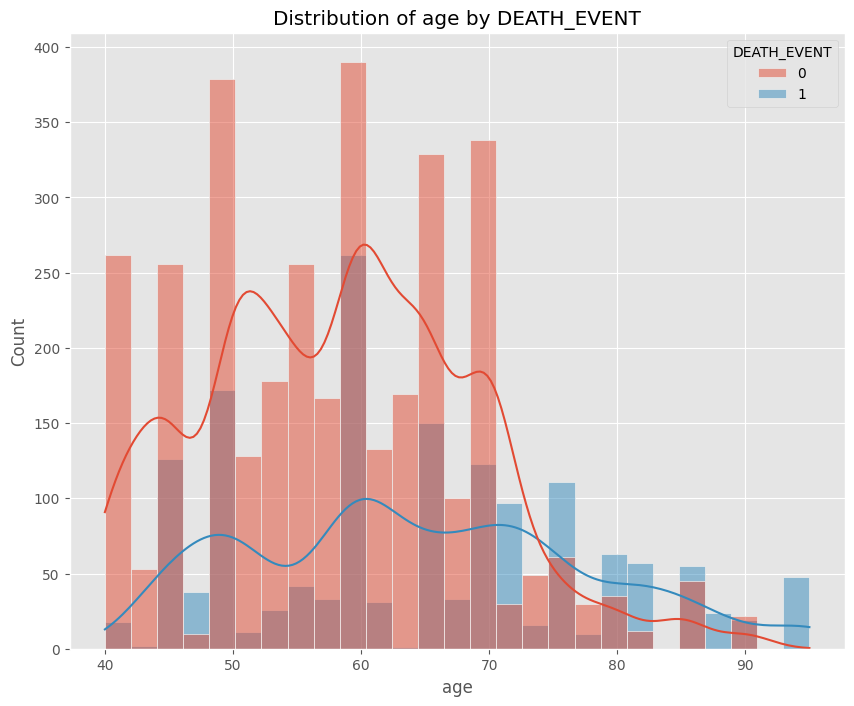

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.histplot(x='age', data=df, kde=True  , hue = 'DEATH_EVENT')
ax.set_title('Distribution of age by DEATH_EVENT')
plt.show()

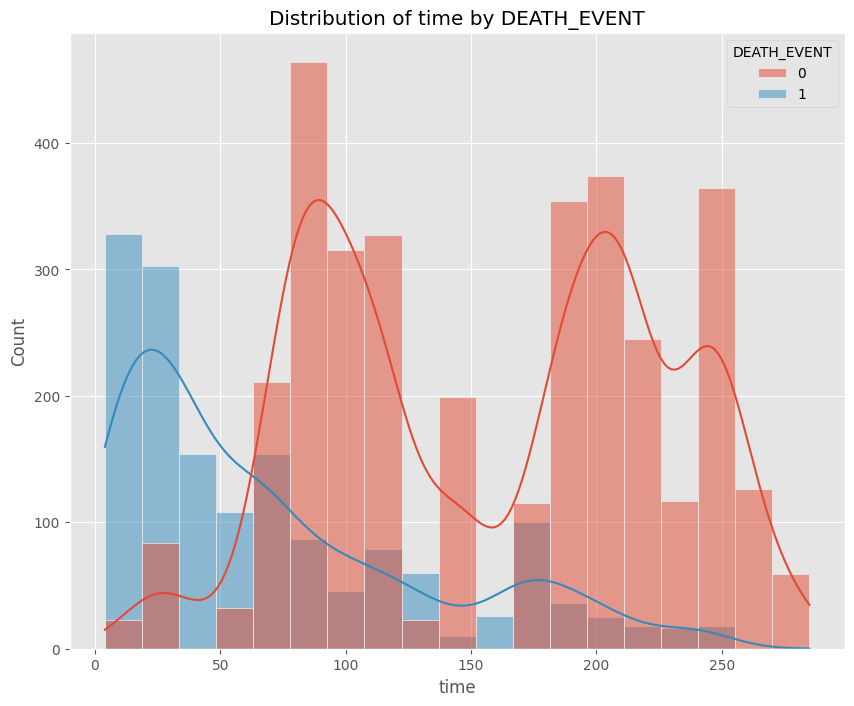

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.histplot(x='time', hue='DEATH_EVENT', data=df, kde=True)
ax.set_title('Distribution of time by DEATH_EVENT')
plt.show()

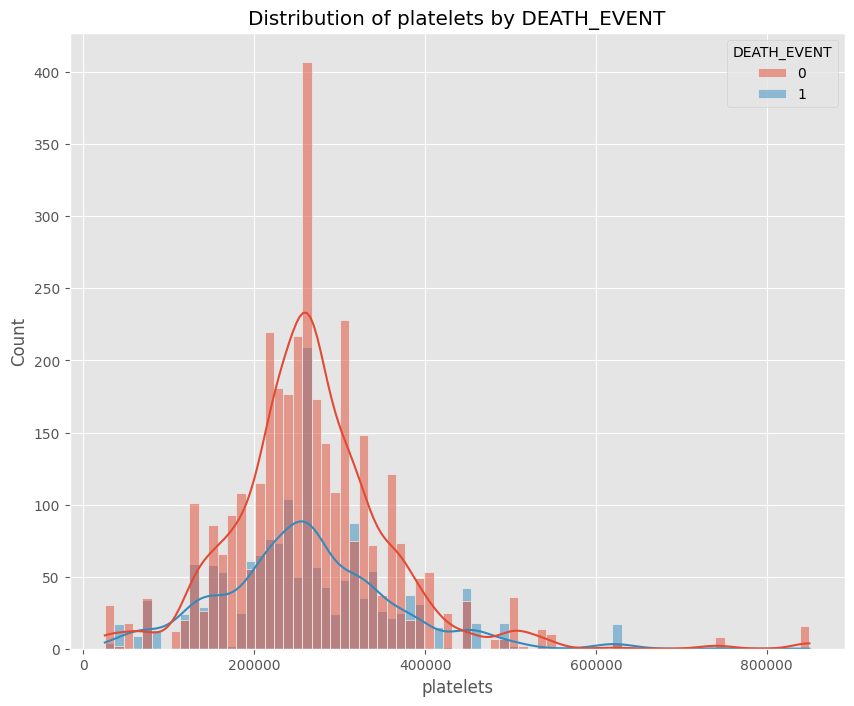

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.histplot(x='platelets', hue='DEATH_EVENT', data=df, kde=True)
ax.set_title('Distribution of platelets by DEATH_EVENT')
plt.show()

In [ ]:
platelets_mean = df.groupby('DEATH_EVENT')['platelets'].mean()
platelets_std = df.groupby('DEATH_EVENT')['platelets'].std()
print('Trung bình platelets theo DEATH_EVENT:\n', platelets_mean.to_frame())
print('Độ lệch chuẩn platelets theo DEATH_EVENT:\n', platelets_std.to_frame())

Trung bình platelets theo DEATH_EVENT:
                  platelets
DEATH_EVENT               
0            267163.177028
1            260505.738705
Độ lệch chuẩn platelets theo DEATH_EVENT:
                  platelets
DEATH_EVENT               
0             96503.667982
1            101078.102673


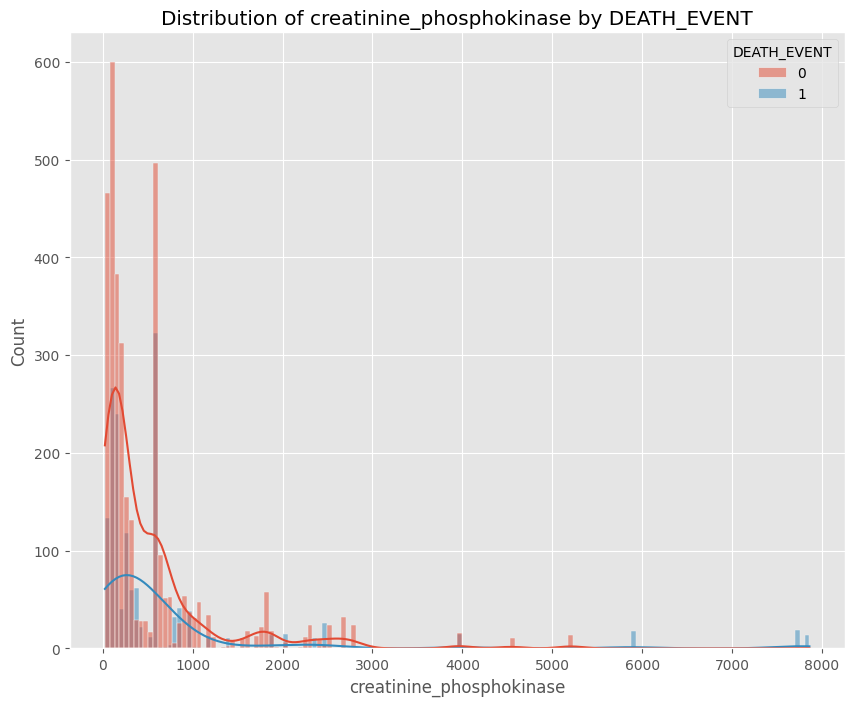

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.histplot(x='creatinine_phosphokinase', hue='DEATH_EVENT', data=df, kde=True)
ax.set_title('Distribution of creatinine_phosphokinase by DEATH_EVENT')
plt.show()

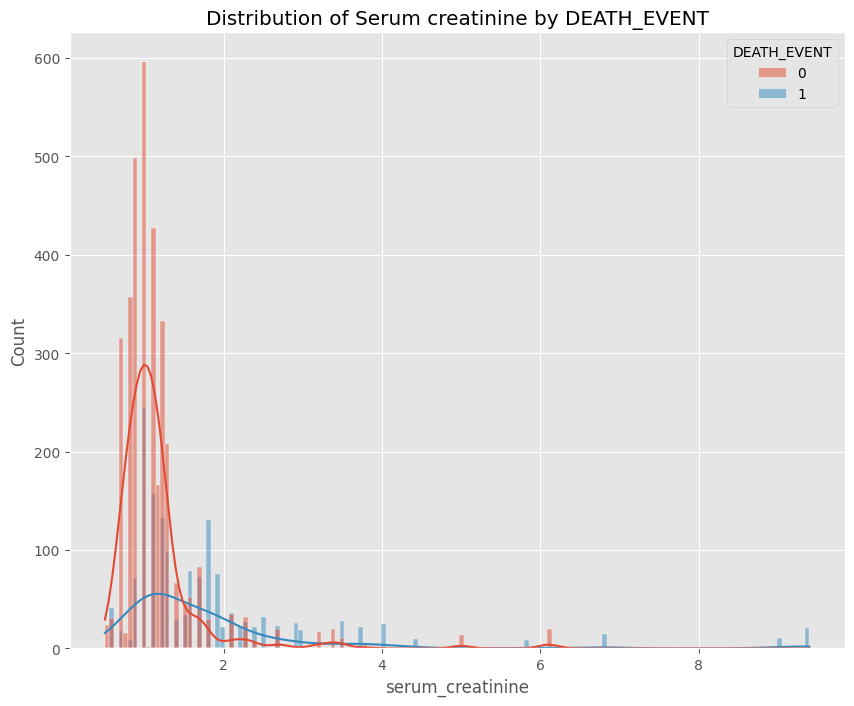

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.histplot(x='serum_creatinine', hue='DEATH_EVENT', data=df, kde=True)
ax.set_title('Distribution of Serum creatinine by DEATH_EVENT')
plt.show()

In [ ]:
serum_creatinine_mean = df.groupby('DEATH_EVENT')['serum_creatinine'].mean()
serum_creatinine_std = df.groupby('DEATH_EVENT')['serum_creatinine'].std()

print('Trung bình serum_creatinine theo DEATH_EVENT:\n', serum_creatinine_mean.to_frame())
print('Độ lệch chuẩn serum_creatinine theo DEATH_EVENT:\n', serum_creatinine_std.to_frame())

Trung bình serum_creatinine theo DEATH_EVENT:
              serum_creatinine
DEATH_EVENT                  
0                    1.156672
1                    1.834075
Độ lệch chuẩn serum_creatinine theo DEATH_EVENT:
              serum_creatinine
DEATH_EVENT                  
0                    0.632067
1                    1.436236


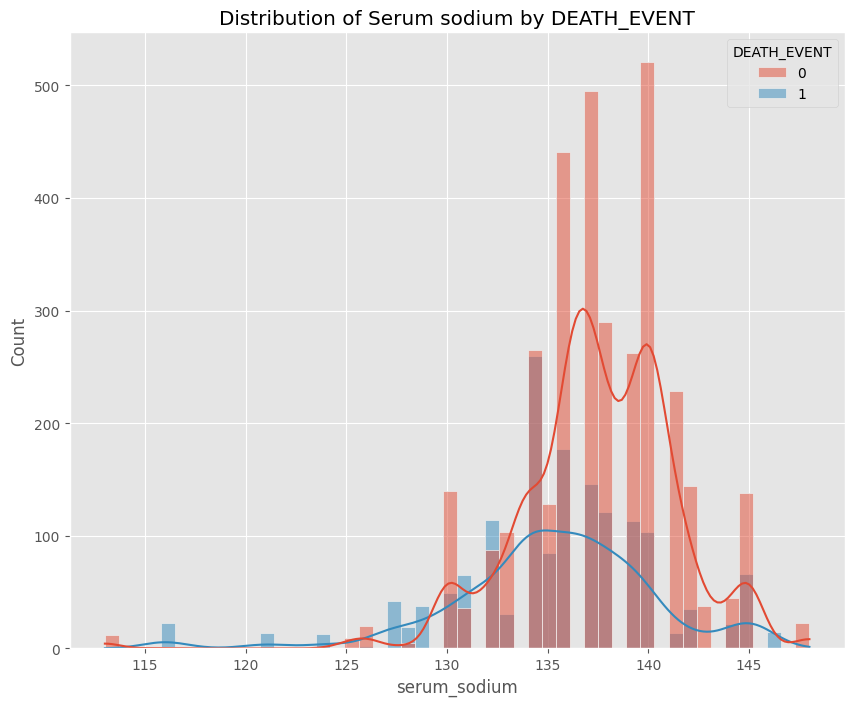

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.histplot(x='serum_sodium', hue='DEATH_EVENT', data=df, kde=True)
ax.set_title('Distribution of Serum sodium by DEATH_EVENT')
plt.show()

In [ ]:
serum_sodium_mean = df.groupby('DEATH_EVENT')['serum_sodium'].mean()
serum_sodium_std = df.groupby('DEATH_EVENT')['serum_sodium'].std()

print('Trung bình serum_sodium theo DEATH_EVENT:\n', serum_sodium_mean.to_frame())
print('Độ lệch chuẩn serum_sodium theo DEATH_EVENT:\n', serum_sodium_std.to_frame())

Trung bình serum_sodium theo DEATH_EVENT:
              serum_sodium
DEATH_EVENT              
0              137.494172
1              135.306760
Độ lệch chuẩn serum_sodium theo DEATH_EVENT:
              serum_sodium
DEATH_EVENT              
0                3.983055
1                5.055244


In [ ]:
plt.figure(figsize=(15,10))
ax = sns.pairplot(df, hue='DEATH_EVENT')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

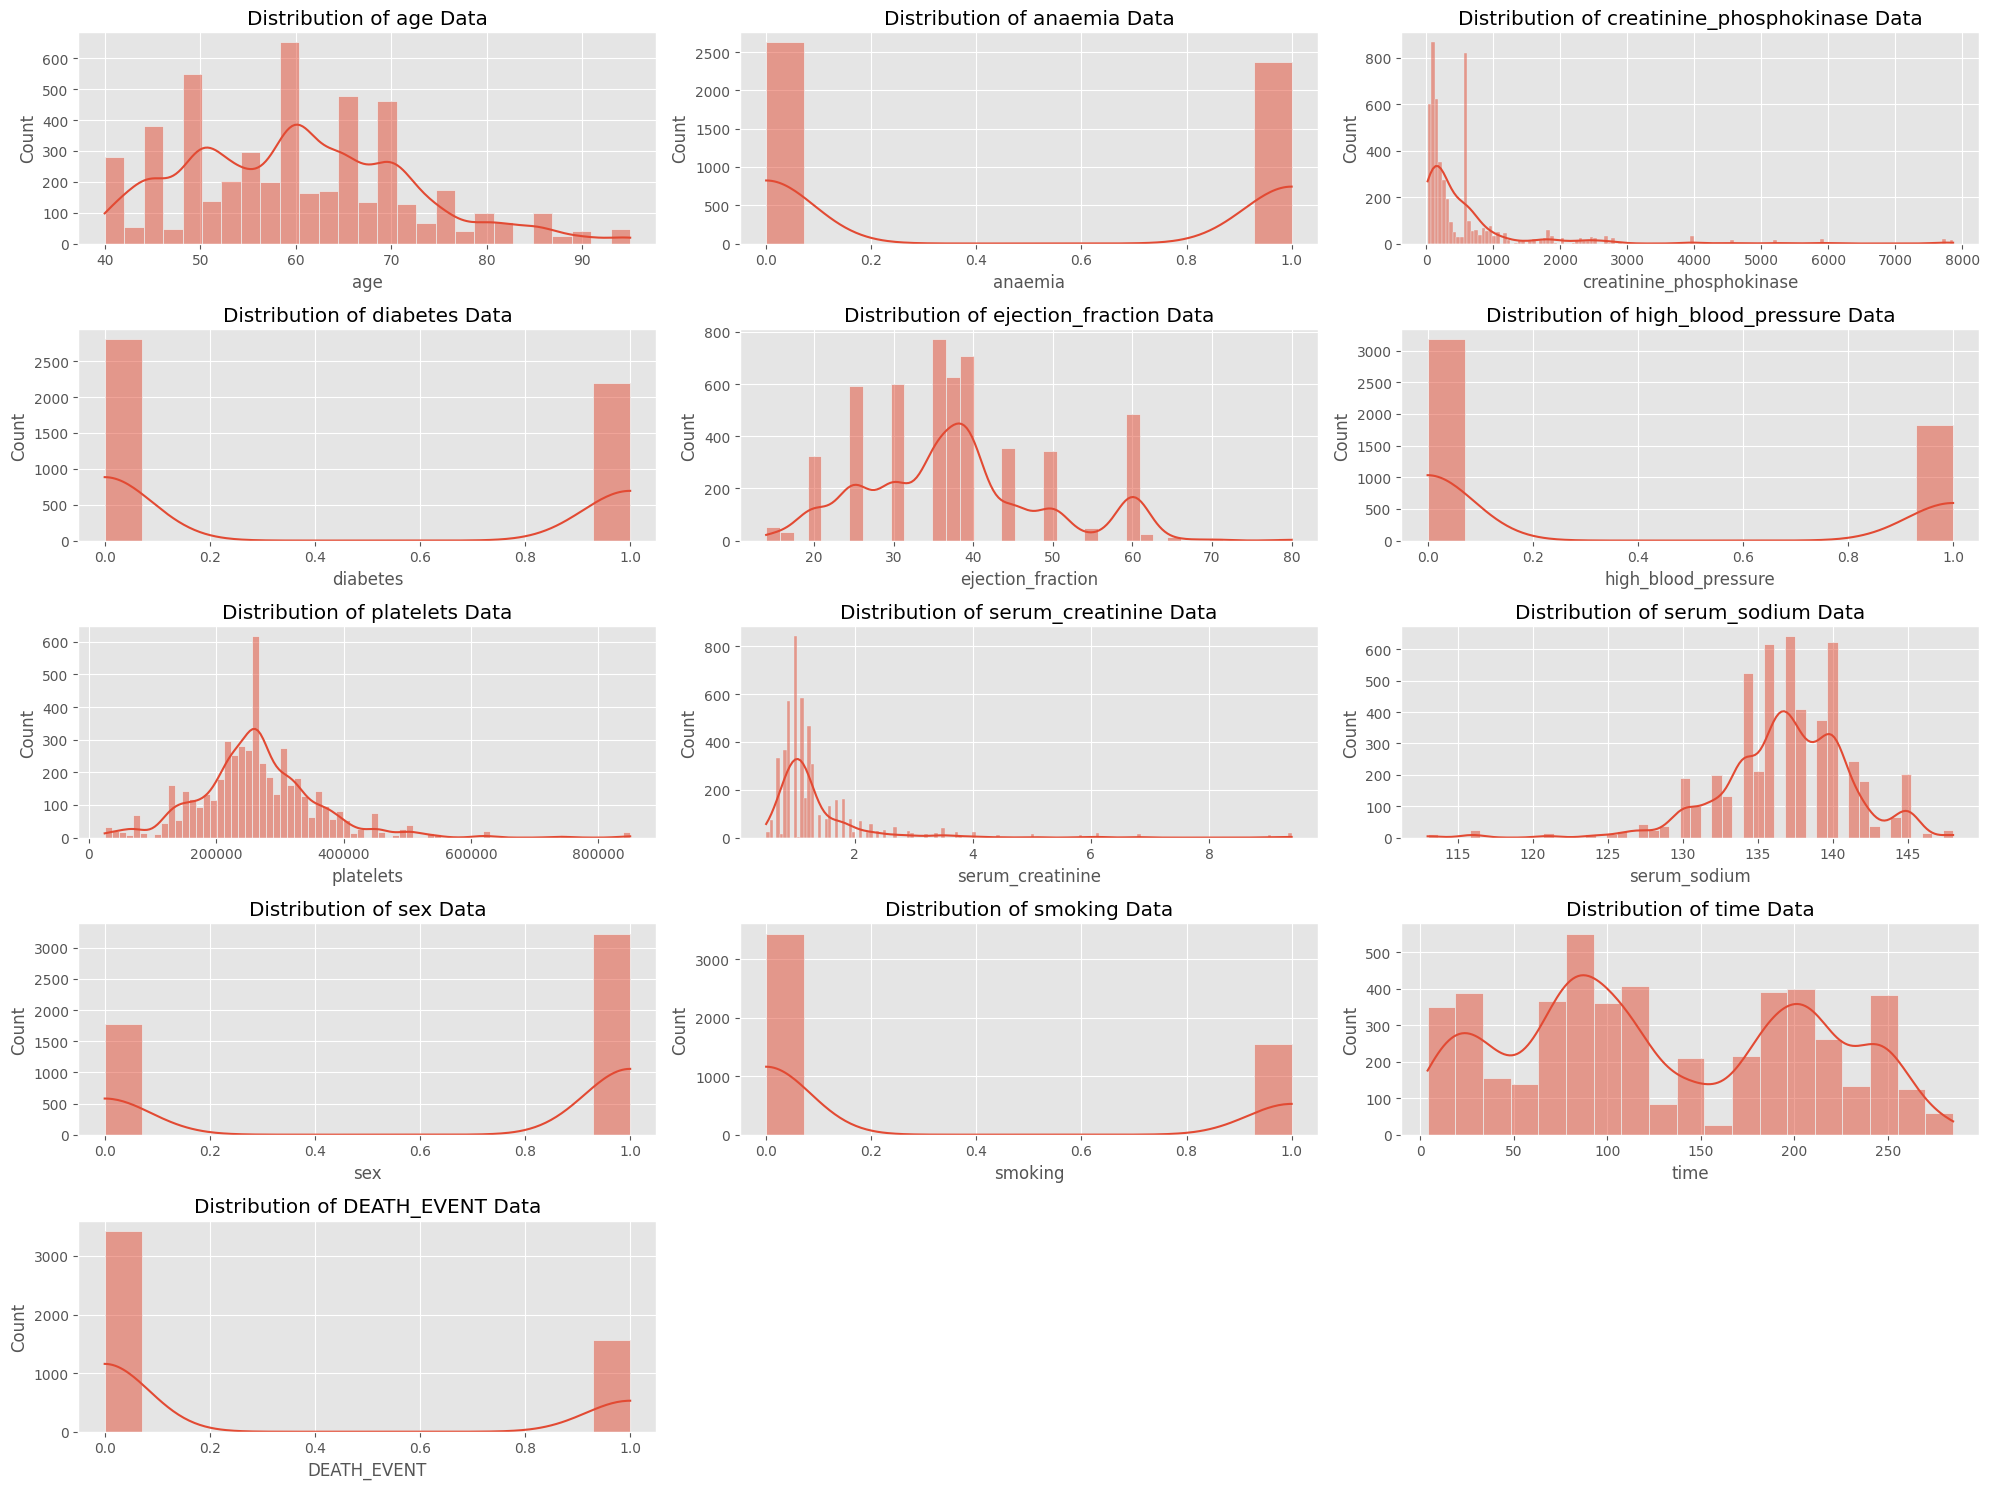

In [ ]:
plt.figure(figsize=(20,15))
for i, col in enumerate(df.columns, 1):
  plt.subplot(5,3,i)
  sns.histplot(df[col] , kde = True)
  plt.title(f"Distribution of {col} Data")
  plt.tight_layout()
  plt.plot()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Tạo figure với 3 hàng, 2 cột (tùy số biến)
fig = make_subplots(rows=3, cols=2,
                    subplot_titles=("Age by DEATH_EVENT",
                                    "Platelets by DEATH_EVENT",
                                    "Creatinine phosphokinase by DEATH_EVENT",
                                    "Serum creatinine by DEATH_EVENT",
                                    "Serum sodium by DEATH_EVENT",
                                    "Ejection fraction by DEATH_EVENT"))

# 1. Age
fig.add_trace(go.Box(y=df['age'], x=df['DEATH_EVENT'], name='Age', marker_color='blue'), row=1, col=1)

# 2. Platelets
fig.add_trace(go.Box(y=df['platelets'], x=df['DEATH_EVENT'], name='Platelets', marker_color='green'), row=1, col=2)

# 3. Creatinine phosphokinase
fig.add_trace(go.Box(y=df['creatinine_phosphokinase'], x=df['DEATH_EVENT'], name='CPK', marker_color='red'), row=2, col=1)

# 4. Serum creatinine
fig.add_trace(go.Box(y=df['serum_creatinine'], x=df['DEATH_EVENT'], name='Serum creatinine', marker_color='orange'), row=2, col=2)

# 5. Serum sodium
fig.add_trace(go.Box(y=df['serum_sodium'], x=df['DEATH_EVENT'], name='Serum sodium', marker_color='purple'), row=3, col=1)

# 6. Ejection fraction
fig.add_trace(go.Box(y=df['ejection_fraction'], x=df['DEATH_EVENT'], name='Ejection fraction', marker_color='pink'), row=3, col=2)

# Cập nhật layout
fig.update_layout(height=1200, width=900, title_text="Distribution of Features by DEATH_EVENT")
fig.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   float64
 1   anaemia                   5000 non-null   int64  
 2   creatinine_phosphokinase  5000 non-null   int64  
 3   diabetes                  5000 non-null   int64  
 4   ejection_fraction         5000 non-null   int64  
 5   high_blood_pressure       5000 non-null   int64  
 6   platelets                 5000 non-null   float64
 7   serum_creatinine          5000 non-null   float64
 8   serum_sodium              5000 non-null   int64  
 9   sex                       5000 non-null   int64  
 10  smoking                   5000 non-null   int64  
 11  time                      5000 non-null   int64  
 12  DEATH_EVENT               5000 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 507.9 KB


In [ ]:
categories_col  = ['anaemia','diabetes' , 'high_blood_pressure' , 'sex' , 'smoking' , 'DEATH_EVENT']
for col in categories_col:
  df[col] = df[col].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       5000 non-null   float64 
 1   anaemia                   5000 non-null   category
 2   creatinine_phosphokinase  5000 non-null   int64   
 3   diabetes                  5000 non-null   category
 4   ejection_fraction         5000 non-null   int64   
 5   high_blood_pressure       5000 non-null   category
 6   platelets                 5000 non-null   float64 
 7   serum_creatinine          5000 non-null   float64 
 8   serum_sodium              5000 non-null   int64   
 9   sex                       5000 non-null   category
 10  smoking                   5000 non-null   category
 11  time                      5000 non-null   int64   
 12  DEATH_EVENT               5000 non-null   category
dtypes: category(6), float64(3), int64(4)
memory usag

In [ ]:
# lấy ra các biến phân loại nhằm dễ dàng sử dụng sau này
df_cate_col = df.drop('DEATH_EVENT', axis = 1).select_dtypes(include='category')
# lấy cac biến còn lại
df_quanti_col = df.drop('DEATH_EVENT', axis = 1).select_dtypes(exclude='category')

In [ ]:
# Kiểm tra lại kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       5000 non-null   float64 
 1   anaemia                   5000 non-null   category
 2   creatinine_phosphokinase  5000 non-null   int64   
 3   diabetes                  5000 non-null   category
 4   ejection_fraction         5000 non-null   int64   
 5   high_blood_pressure       5000 non-null   category
 6   platelets                 5000 non-null   float64 
 7   serum_creatinine          5000 non-null   float64 
 8   serum_sodium              5000 non-null   int64   
 9   sex                       5000 non-null   category
 10  smoking                   5000 non-null   category
 11  time                      5000 non-null   int64   
 12  DEATH_EVENT               5000 non-null   category
dtypes: category(6), float64(3), int64(4)
memory usag

In [ ]:
# kiểm tra dữ liệu thiếu trong tập dữ liệu|
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


#Xử lý outline

In [ ]:
from typing import Tuple
from sklearn.base import BaseEstimator , TransformerMixin

def box_plot_boudaries( col : pd.Series , wisker_coff:float = 1.5 ) -> Tuple[float,float]  :
  #tìm max, min của boxplot
  q1 = col.quantile(0.25)
  q3 = col.quantile(0.75)
  iqr = q3 - q1
  lower = q1 - wisker_coff * iqr
  upper = q3 + wisker_coff * iqr
  return lower , upper
class OutlierClipping(BaseEstimator, TransformerMixin):
  def __init__(self, wisker_coff:float = 1.5):
    self.wisker_coff = wisker_coff
    self.lower = None
    self.upper = None
  def fit(self, X: pd.Series ):
    self.lower , self.upper = box_plot_boudaries(X , wisker_coff=self.wisker_coff)
    return self
  def transform(self , X):
    return X.clip(self.lower , self.upper)

In [ ]:
df['age'] = OutlierClipping().fit_transform(df['age'])


In [ ]:
fig = px.box(df,y="age",title=f"Distrubution of Age" )
fig.show()

In [ ]:
df['platelets'] = OutlierClipping().fit_transform(df['platelets'])
fig = px.box(df,y="platelets",title=f"Distrubution of Platelets" )
fig.show()

In [ ]:
df['creatinine_phosphokinase'] = OutlierClipping().fit_transform(df['creatinine_phosphokinase'])
fig = px.box(df,y="creatinine_phosphokinase",title=f"Distrubution of Creatinine phosphokinase" )
fig.show()

In [ ]:
df['serum_creatinine'] = OutlierClipping().fit_transform(df['serum_creatinine'])
fig = px.box(df,y="serum_creatinine",title=f"Distrubution of Serum creatinine" )
fig.show()

In [ ]:
df['ejection_fraction'] = OutlierClipping().fit_transform(df['ejection_fraction'])
fig = px.box(df,y="ejection_fraction",title=f"Distrubution of Ejection fraction" )
fig.show()

In [ ]:
df['serum_sodium'] = OutlierClipping().fit_transform(df['serum_sodium'])
fig = px.box(df,y="serum_sodium",title=f"Distrubution of Serum_sodium" )
fig.show()

In [ ]:
df['serum_sodium'] = OutlierClipping().fit_transform(df['serum_sodium'])
fig = px.box(df,y="serum_sodium",title=f"Distrubution of Serum_sodium " )
fig.show()

# Chuẩn hóa

In [ ]:
scaler = preprocessing.MinMaxScaler()
df_quanti_col = scaler.fit_transform(df_quanti_col)

<Axes: ylabel='Density'>

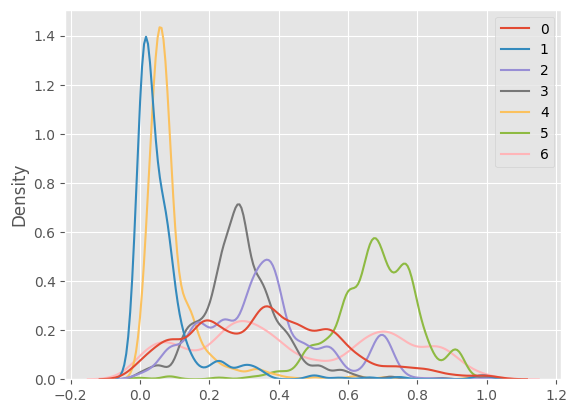

In [ ]:
sns.kdeplot(df_quanti_col)

In [ ]:
import plotly.express as px
import pandas as pd

# Giả sử df_cate_col là DataFrame chứa các cột phân loại
df_cate_long = df_cate_col.melt(var_name="Category", value_name="Value")

# Vẽ boxplot với mỗi cột 1 màu khác nhau
fig = px.box(df_cate_long, x="Category", y="Value", color="Category")
fig.update_layout(title="Boxplot of Categorical Features")
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px
from sklearn import preprocessing

# Lấy danh sách các cột định lượng từ df gốc
quanti_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Scale về [0,1]
scaler = preprocessing.MinMaxScaler()
df_quanti_scaled = pd.DataFrame(
    scaler.fit_transform(df[quanti_cols]),
    columns=quanti_cols   # giữ lại tên cột gốc
)

# Chuyển wide -> long
df_quanti_long = df_quanti_scaled.melt(var_name="Feature", value_name="Value")

# Vẽ boxplot
fig = px.box(df_quanti_long, x="Feature", y="Value", color="Feature")
fig.update_layout(title="Boxplot of Quantitative Features (Scaled to [0,1])")
fig.show()



# xử lý biến phân loại

In [ ]:
df.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,748.0,0,45.0,0,263358.03,1.30,137,1,1,88,0
1,65.0,0,56.0,0,25.0,0,305000.00,2.15,130,1,0,207,0
2,45.0,0,582.0,1,38.0,0,319000.00,0.90,140,0,0,244,0
3,60.0,1,754.0,1,40.0,1,328000.00,1.20,126,1,0,90,0
4,95.0,1,582.0,0,30.0,0,452500.00,2.00,132,1,0,50,1
5,70.0,0,232.0,1,30.0,0,302000.00,1.20,132,1,0,210,0
6,63.0,1,122.0,1,60.0,0,172000.00,1.20,145,0,0,147,0
7,70.0,1,171.0,0,50.0,1,358000.00,0.90,141,0,0,196,0
8,50.0,0,482.0,1,30.0,0,300000.00,0.90,132,1,0,109,0
9,53.0,1,446.0,0,45.0,1,274000.00,1.00,133,1,0,215,0


# LỰA CHỌN CROSS-VALIDATION

In [ ]:
df['DEATH_EVENT'].value_counts(normalize=True)

,proportion
DEATH_EVENT,
0,0.6864
1,0.3136


# Tách biến phụ thuộc & độc lập

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)


In [ ]:
X = df.drop('DEATH_EVENT', axis=1)   # biến độc lập
y = df['DEATH_EVENT']                # biến phụ thuộc

# Chia dữ liệu bằng Stratified K-Fold

In [ ]:
n_splits = 10
kf = model_selection.StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)


# Huấn luyện & dự đoán với Logistic Regression

In [ ]:
# Lưu kết quả
metrics_log = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-score": [],
    "ROC-AUC": []
}
# Lưu kết quả ROC cho Logistic Regression
y_score_log_all = []
y_val_log_all = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    clf = LogisticRegression(random_state=42, max_iter=1000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    y_score = clf.predict_proba(X_val)[:, 1]  # xác suất nhãn 1
    # Tính các độ đo
    metrics_log["Accuracy"].append(accuracy_score(y_val, y_pred))
    metrics_log["Precision"].append(precision_score(y_val, y_pred))
    metrics_log["Recall"].append(recall_score(y_val, y_pred))
    metrics_log["F1-score"].append(f1_score(y_val, y_pred))
    metrics_log["ROC-AUC"].append(roc_auc_score(y_val, y_score))
    # Lưu nhãn thật và xác suất
    y_score_log_all.extend(y_score)
    y_val_log_all.extend(y_val)

    print(f"---- Fold {fold+1} ----")
    print(classification_report(y_val, y_pred))


---- Fold 1 ----
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       344
           1       0.77      0.73      0.75       156

    accuracy                           0.85       500
   macro avg       0.83      0.82      0.82       500
weighted avg       0.85      0.85      0.85       500

---- Fold 2 ----
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       344
           1       0.74      0.69      0.72       156

    accuracy                           0.83       500
   macro avg       0.80      0.79      0.80       500
weighted avg       0.83      0.83      0.83       500

---- Fold 3 ----
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       343
           1       0.75      0.72      0.73       157

    accuracy                           0.84       500
   macro avg       0.81      0.80      0.81       500
weighted avg       0.83

In [ ]:
df_log = pd.DataFrame({'Actual/ DL thực':y_val, 'Predicted/ Dự đoán':y_pred})
df_log

,Actual/ DL thực,Predicted/ Dự đoán
2,0,0
3,0,0
11,1,1
15,1,0
21,0,0
...,...,...
4964,1,0
4975,0,1
4979,0,0
4991,0,0


# Trực quan hóa kết quả


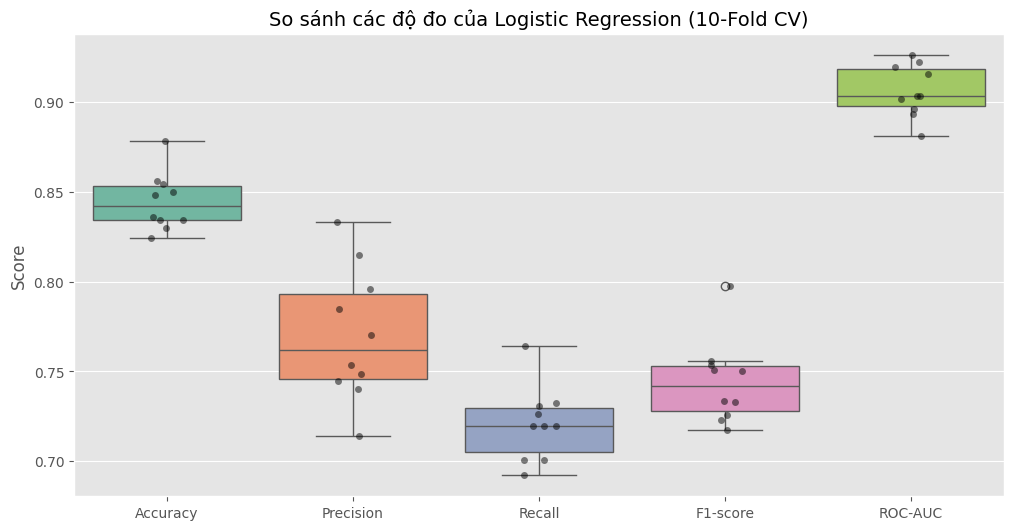

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=pd.DataFrame(metrics_log), palette="Set2")
sns.stripplot(data=pd.DataFrame(metrics_log), color="black", alpha=0.5)

plt.title("So sánh các độ đo của Logistic Regression (10-Fold CV)", fontsize=14)
plt.ylabel("Score")
plt.show()


<Figure size 1200x600 with 0 Axes>

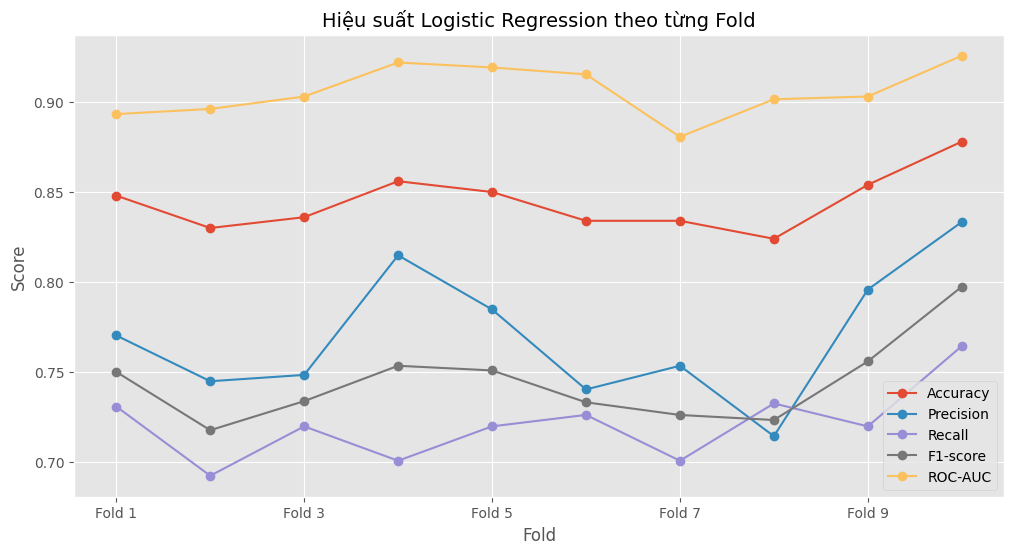

In [ ]:
plt.figure(figsize=(12,6))
df_metrics_log = pd.DataFrame(metrics_log)  # metrics_log là dict các độ đo của Logistic
df_metrics_log.index = [f"Fold {i+1}" for i in range(n_splits)]
df_metrics_log.plot(marker="o", figsize=(12,6))

plt.title("Hiệu suất Logistic Regression theo từng Fold", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Fold")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


<Figure size 1400x800 with 0 Axes>

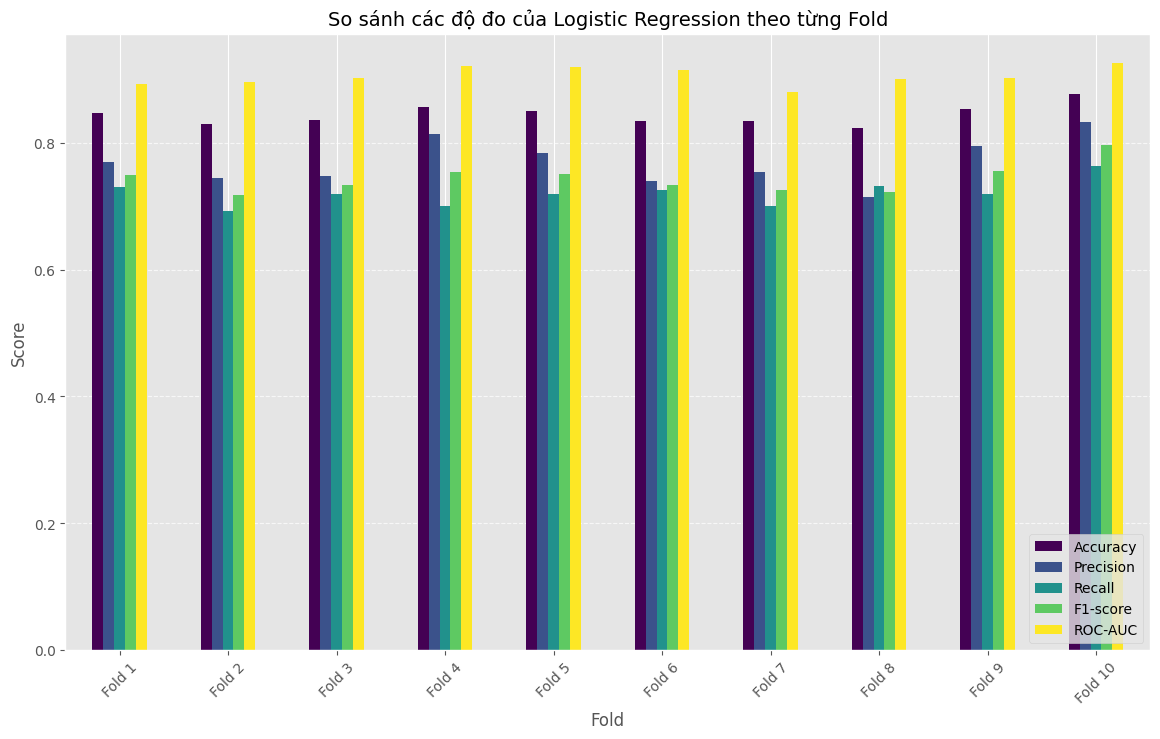

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_metrics_log = pd.DataFrame(metrics_log)  # metrics_log là dict các độ đo Logistic
df_metrics_log.index = [f"Fold {i+1}" for i in range(n_splits)]

plt.figure(figsize=(14,8))
df_metrics_log.plot(kind="bar", figsize=(14,8), colormap="viridis")

plt.title("So sánh các độ đo của Logistic Regression theo từng Fold", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Fold")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



# Đánh giá mô hình

In [ ]:
for m in metrics_log:
    print(f"{m}: {np.mean(metrics_log[m]):.3f} (± {np.std(metrics_log[m]):.3f})")


Accuracy: 0.844 (± 0.015)
Precision: 0.770 (± 0.035)
Recall: 0.721 (± 0.019)
F1-score: 0.744 (± 0.022)
ROC-AUC: 0.906 (± 0.014)


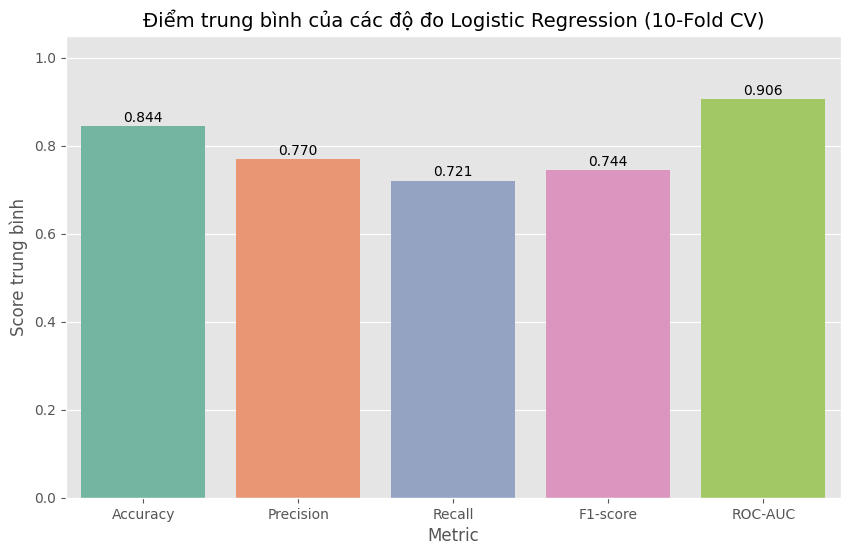

In [ ]:
# Tính điểm trung bình từng độ đo cho Logistic Regression
mean_scores_log = df_metrics_log.mean()

plt.figure(figsize=(10,6))
sns.barplot(x=mean_scores_log.index, y=mean_scores_log.values, palette="Set2")

for i, v in enumerate(mean_scores_log.values):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', fontsize=10)

plt.title("Điểm trung bình của các độ đo Logistic Regression (10-Fold CV)", fontsize=14)
plt.ylabel("Score trung bình")
plt.xlabel("Metric")
plt.ylim(0,1.05)
plt.show()



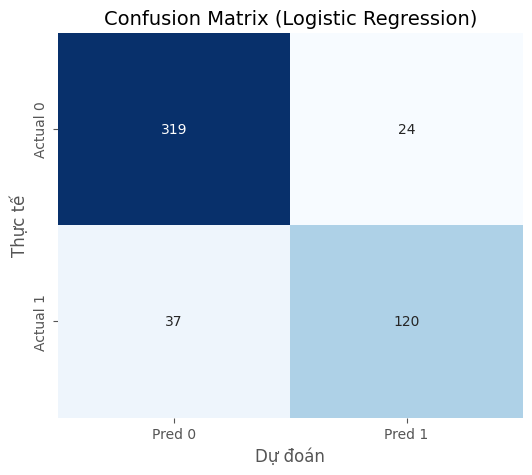

In [ ]:
# Ma trận nhầm lẫn cho Logistic Regression
cm_log = confusion_matrix(y_val, y_pred)
df_cm_log = pd.DataFrame(cm_log,
                         index=[f"Actual {i}" for i in range(cm_log.shape[0])],
                         columns=[f"Pred {i}" for i in range(cm_log.shape[1])])

plt.figure(figsize=(6,5))
sns.heatmap(df_cm_log, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (Logistic Regression)", fontsize=14)
plt.ylabel("Thực tế")
plt.xlabel("Dự đoán")
plt.show()
